# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The AI Job Market Dataset](https://www.kaggle.com/datasets/alitaqishah/ai-jobs-market-2025-2026-salaries)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('ai_jobs_market_2025_2026.csv')

# Preprocessing

## Frist five row

In [3]:
pd.set_option('display.max_columns', None)
df.head()

,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,country,remote_work,company_size,industry,required_skills,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,USA,On-site,Startup (1-50),Finance,APIs|Planning Systems|Python|Cloud|SQL|Leadership,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,UK,Hybrid,Enterprise (5000+),Finance,Python|Documentation|LLM APIs|Prompt Design|NL...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,USA,Fully Remote,Big Tech (FAANG+),Finance,Vector DBs|Python|Prompt Engineering|Fine-tuni...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,Singapore,Fully Remote,SME (51-500),Technology,Feature Stores|Spark|ETL|Airflow|dbt|SQL|Pytho...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,USA,Fully Remote,Enterprise (5000+),Automotive,Data Analysis|Stakeholder Mgmt|Agile|Cloud|Pro...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)


## last Five row

In [4]:
df.tail()

,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,country,remote_work,company_size,industry,required_skills,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
1495,AIJOB1496,Multimodal AI Engineer,AI Engineering,Lead (10+ yrs),8,Master's,262000.0,160000,300000,Toronto,Canada,Hybrid,SME (51-500),Retail,Python|Vision-Language Models|Fine-tuning|PyTo...,8.8,90,23.6,7.5,2026,1,1,1,0,Senior ($200-300k)
1496,AIJOB1497,NLP Engineer,AI Engineering,Senior (6-9 yrs),9,Bootcamp/Self-taught,163000.0,145000,290000,Berlin,Germany,On-site,Mid-size (501-5000),Manufacturing,Transformers|Text Processing|LLMs|Hugging Face...,6.7,91,66.5,7.8,2025,3,1,0,0,Upper-Mid ($150-200k)
1497,AIJOB1498,AI Compliance Manager,Governance,Mid (3-5 yrs),10,Master's,127000.0,100000,200000,Zurich,Switzerland,Hybrid,SME (51-500),Manufacturing,Documentation|Risk Management|Legal Knowledge|...,10.9,68,15.3,8.3,2026,3,0,1,0,Mid ($100-150k)
1498,AIJOB1499,NLP Engineer,AI Engineering,Lead (10+ yrs),4,Bachelor's,145000.0,145000,290000,Bangalore,India,Hybrid,Enterprise (5000+),Media,LLMs|Hugging Face|Python|Transformers|BERT|Tex...,8.5,91,78.8,7.4,2025,5,1,1,0,Mid ($100-150k)
1499,AIJOB1500,AI Security Engineer,Security,Lead (10+ yrs),5,Master's,229000.0,140000,260000,Berlin,Germany,Hybrid,Enterprise (5000+),Technology,Cybersecurity|ML Security|Red Teaming|Python|R...,12.2,80,9.0,8.6,2025,6,1,1,0,Senior ($200-300k)


## Shape of our dataset

In [5]:
df.shape

(1500, 25)

## List out all columns

In [6]:
df.columns

Index(['job_id', 'job_title', 'job_category', 'experience_level',
       'years_of_experience', 'education_required', 'annual_salary_usd',
       'salary_min_usd', 'salary_max_usd', 'city', 'country', 'remote_work',
       'company_size', 'industry', 'required_skills', 'ai_salary_premium_pct',
       'demand_score', 'demand_growth_yoy_pct', 'benefits_score_10',
       'posting_year', 'posting_month', 'is_senior', 'is_remote_friendly',
       'is_llm_role', 'salary_tier'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

job_id                    object
job_title                 object
job_category              object
experience_level          object
years_of_experience        int64
education_required        object
annual_salary_usd        float64
salary_min_usd             int64
salary_max_usd             int64
city                      object
country                   object
remote_work               object
company_size              object
industry                  object
required_skills           object
ai_salary_premium_pct    float64
demand_score               int64
demand_growth_yoy_pct    float64
benefits_score_10        float64
posting_year               int64
posting_month              int64
is_senior                  int64
is_remote_friendly         int64
is_llm_role                int64
salary_tier               object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   job_id                 1500 non-null   object 
 1   job_title              1500 non-null   object 
 2   job_category           1500 non-null   object 
 3   experience_level       1500 non-null   object 
 4   years_of_experience    1500 non-null   int64  
 5   education_required     1500 non-null   object 
 6   annual_salary_usd      1500 non-null   float64
 7   salary_min_usd         1500 non-null   int64  
 8   salary_max_usd         1500 non-null   int64  
 9   city                   1500 non-null   object 
 10  country                1500 non-null   object 
 11  remote_work            1500 non-null   object 
 12  company_size           1500 non-null   object 
 13  industry               1500 non-null   object 
 14  required_skills        1500 non-null   object 
 15  ai_s

## Check Null Value

In [9]:
df.isnull().sum()

job_id                   0
job_title                0
job_category             0
experience_level         0
years_of_experience      0
education_required       0
annual_salary_usd        0
salary_min_usd           0
salary_max_usd           0
city                     0
country                  0
remote_work              0
company_size             0
industry                 0
required_skills          0
ai_salary_premium_pct    0
demand_score             0
demand_growth_yoy_pct    0
benefits_score_10        0
posting_year             0
posting_month            0
is_senior                0
is_remote_friendly       0
is_llm_role              0
salary_tier              0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,years_of_experience,annual_salary_usd,salary_min_usd,salary_max_usd,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,6.216000,194892.000000,135448.666667,257537.333333,10.858200,87.523333,31.116333,7.897333,2025.584000,3.968000,0.496667,0.754000,0.218000
std,2.675216,66506.822013,24448.950878,39852.822207,4.029742,8.026315,22.046343,1.102846,0.493058,3.270388,0.500156,0.430822,0.413025
min,1.000000,90000.000000,90000.000000,180000.000000,3.000000,68.000000,5.000000,6.000000,2025.000000,1.000000,0.000000,0.000000,0.000000
25%,4.000000,144750.000000,120000.000000,218000.000000,8.200000,82.000000,15.375000,6.900000,2025.000000,2.000000,0.000000,1.000000,0.000000
50%,6.000000,180000.000000,140000.000000,270000.000000,10.500000,89.000000,23.400000,7.900000,2026.000000,3.000000,0.000000,1.000000,0.000000
75%,8.000000,236250.000000,155000.000000,290000.000000,14.200000,95.000000,42.700000,8.900000,2026.000000,5.000000,1.000000,1.000000,0.000000
max,15.000000,384000.000000,180000.000000,320000.000000,18.000000,98.000000,87.800000,9.800000,2026.000000,12.000000,1.000000,1.000000,1.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

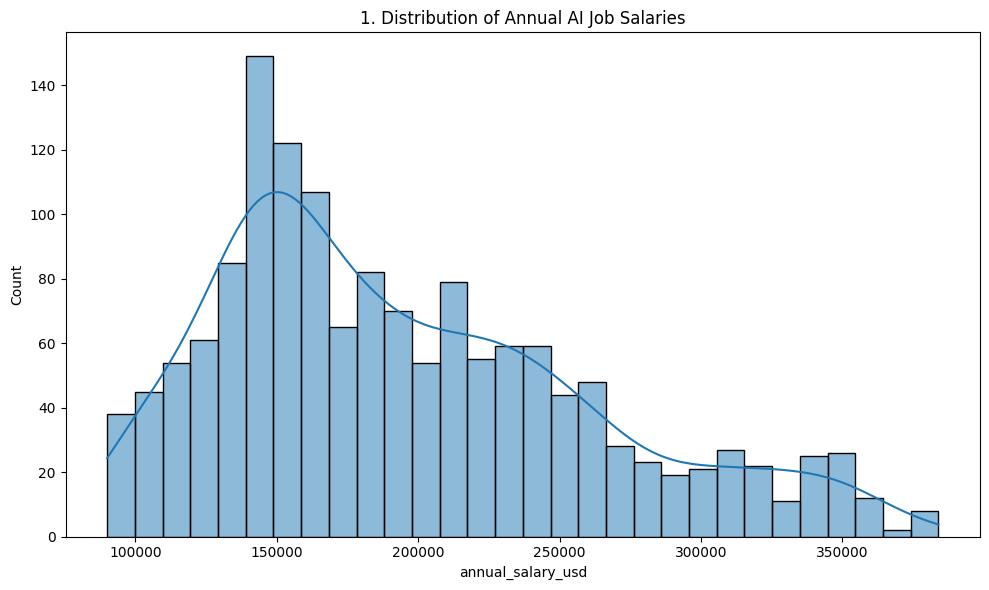

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='annual_salary_usd', kde=True, bins=30)
plt.title(f'{plot_no}. Distribution of Annual AI Job Salaries')
show_fig()
plot_no += 1

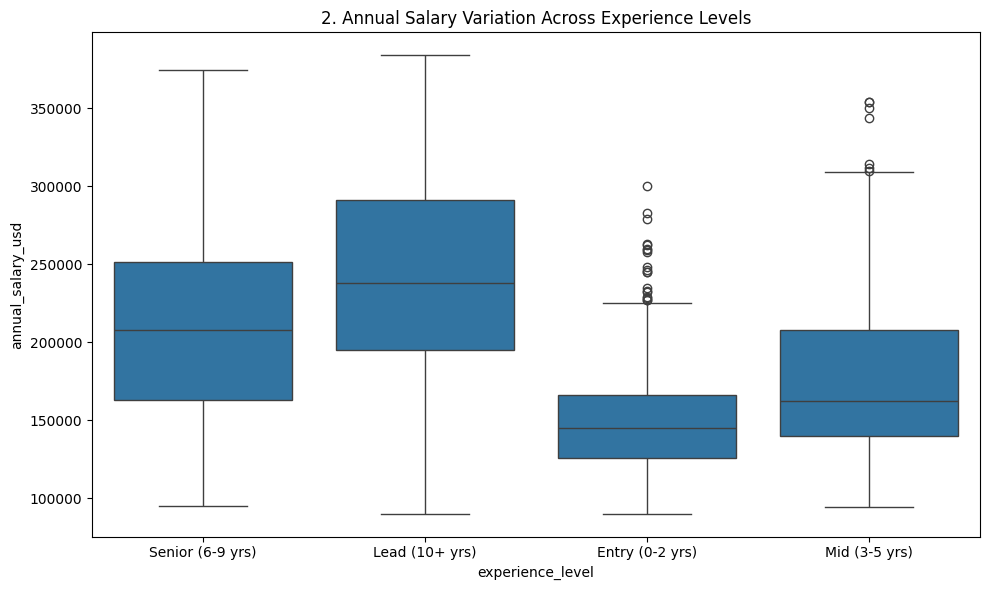

In [14]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='experience_level', y='annual_salary_usd')
plt.title(f'{plot_no}. Annual Salary Variation Across Experience Levels')
show_fig()
plot_no += 1

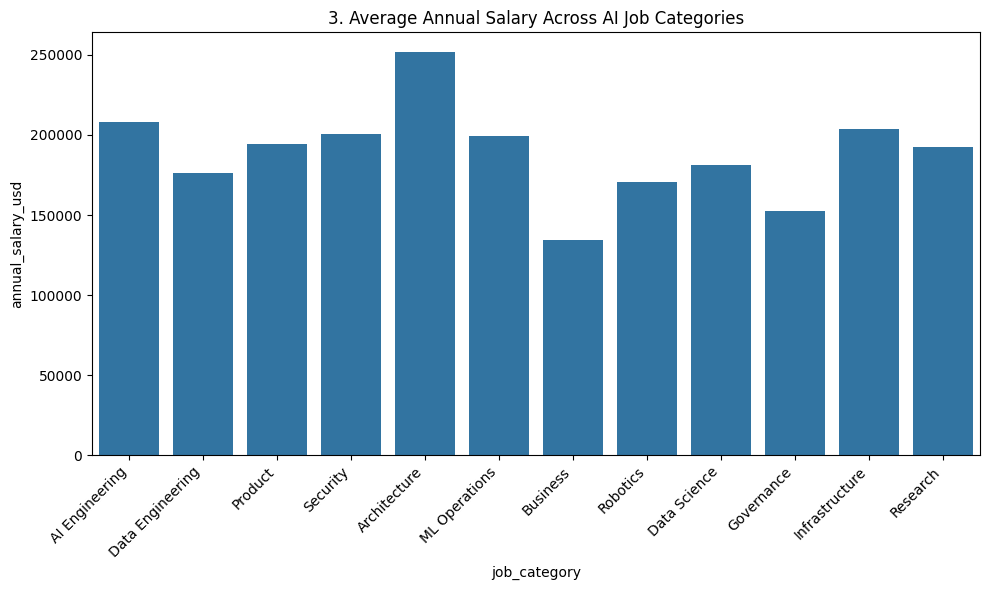

In [15]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='job_category', y='annual_salary_usd', errorbar=None)
plt.title(f'{plot_no}. Average Annual Salary Across AI Job Categories')
plt.xticks(rotation=45, ha='right')
show_fig()
plot_no += 1

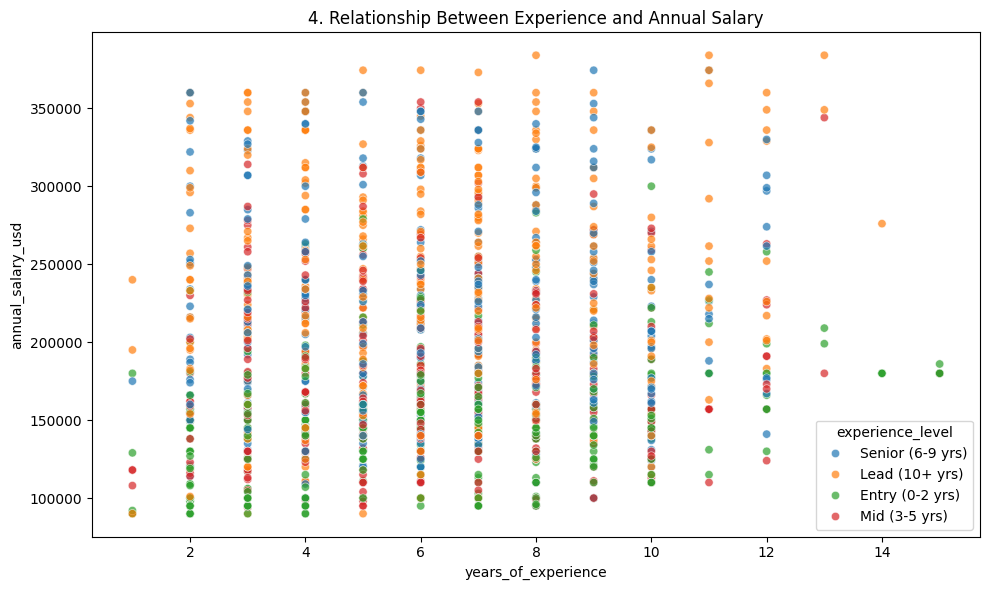

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='years_of_experience', y='annual_salary_usd', hue='experience_level', alpha=0.7)
plt.title(f'{plot_no}. Relationship Between Experience and Annual Salary')
show_fig()
plot_no += 1

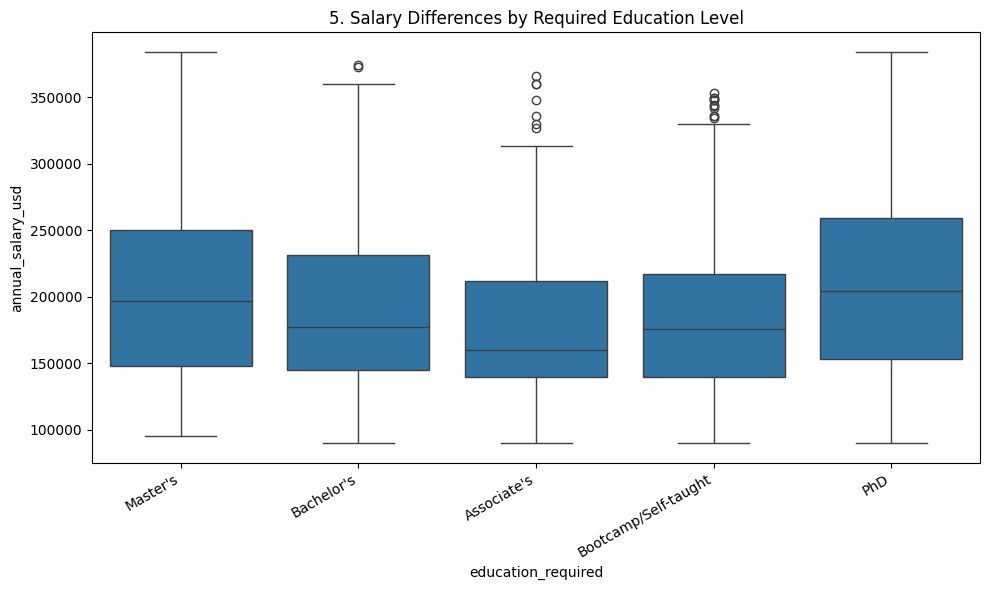

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='education_required', y='annual_salary_usd')
plt.title(f'{plot_no}. Salary Differences by Required Education Level')
plt.xticks(rotation=30, ha='right')
show_fig()
plot_no += 1

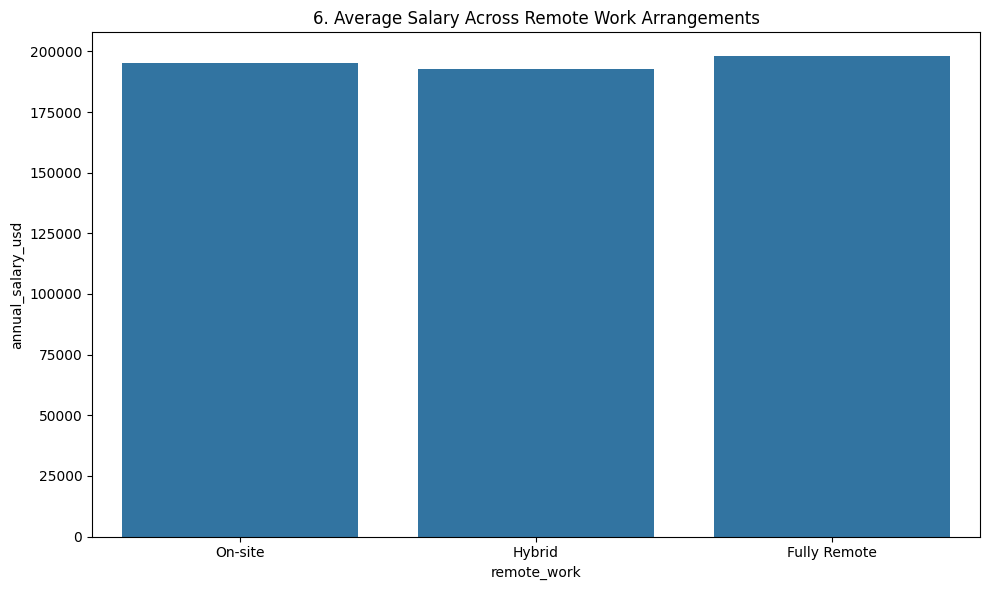

In [18]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='remote_work', y='annual_salary_usd', errorbar=None)
plt.title(f'{plot_no}. Average Salary Across Remote Work Arrangements')
show_fig()
plot_no += 1

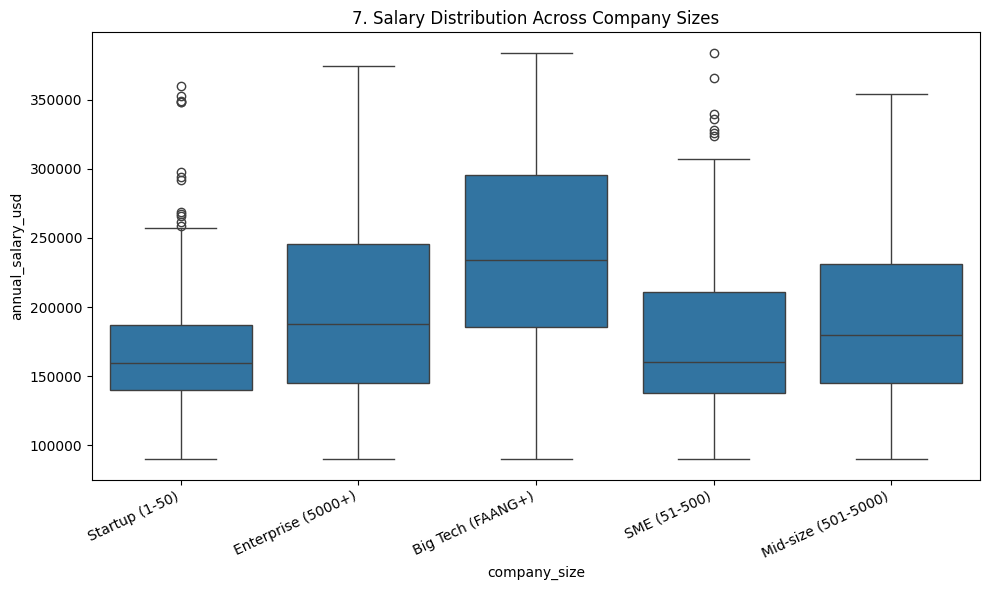

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='company_size', y='annual_salary_usd')
plt.title(f'{plot_no}. Salary Distribution Across Company Sizes')
plt.xticks(rotation=25, ha='right')
show_fig()
plot_no += 1

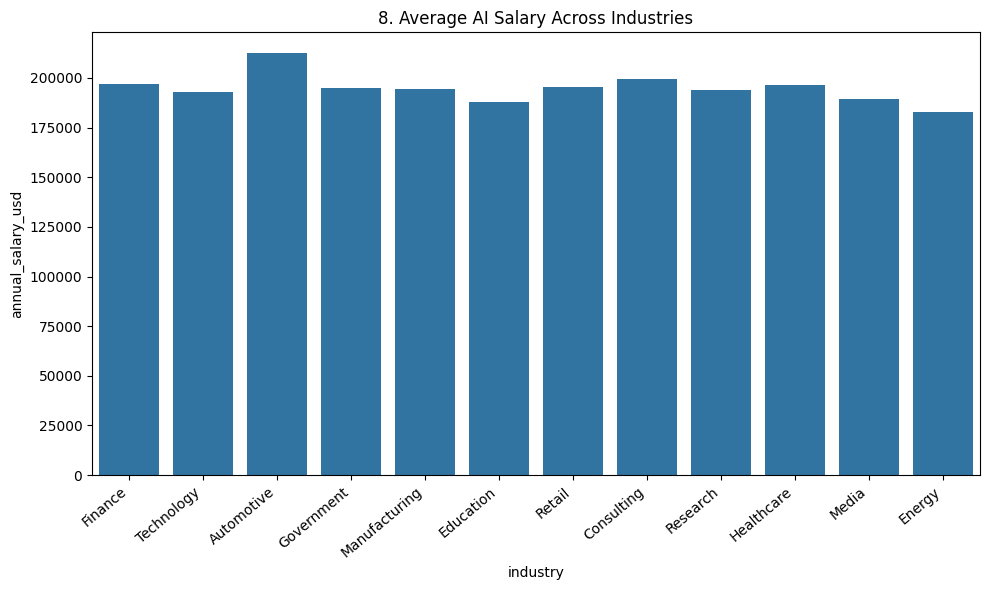

In [20]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='industry', y='annual_salary_usd', errorbar=None)
plt.title(f'{plot_no}. Average AI Salary Across Industries')
plt.xticks(rotation=40, ha='right')
show_fig()
plot_no += 1

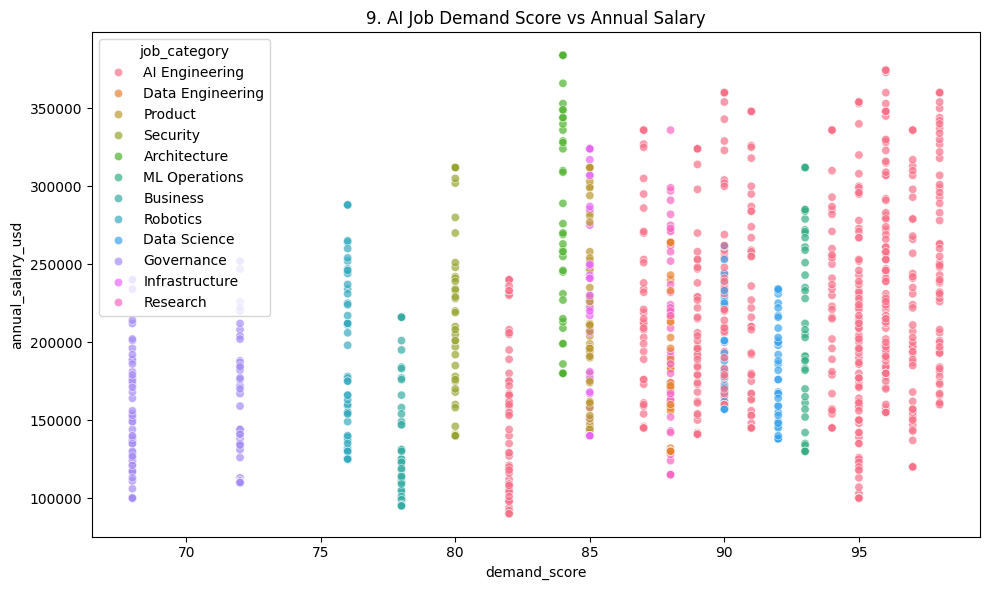

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='demand_score', y='annual_salary_usd', hue='job_category', alpha=0.7)
plt.title(f'{plot_no}. AI Job Demand Score vs Annual Salary')
show_fig()
plot_no += 1

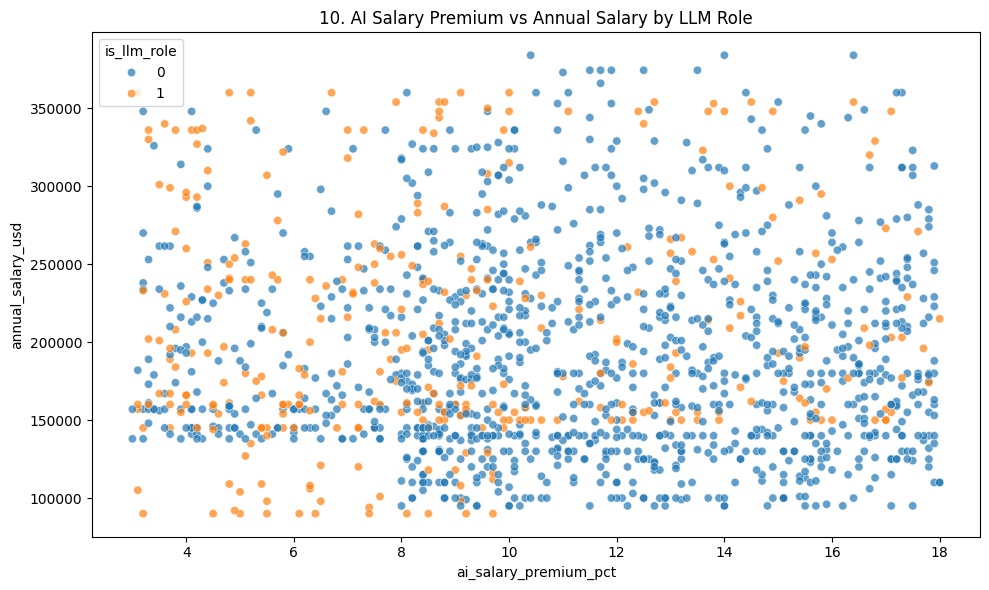

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='ai_salary_premium_pct', y='annual_salary_usd', hue='is_llm_role', alpha=0.7)
plt.title(f'{plot_no}. AI Salary Premium vs Annual Salary by LLM Role')
show_fig()
plot_no += 1

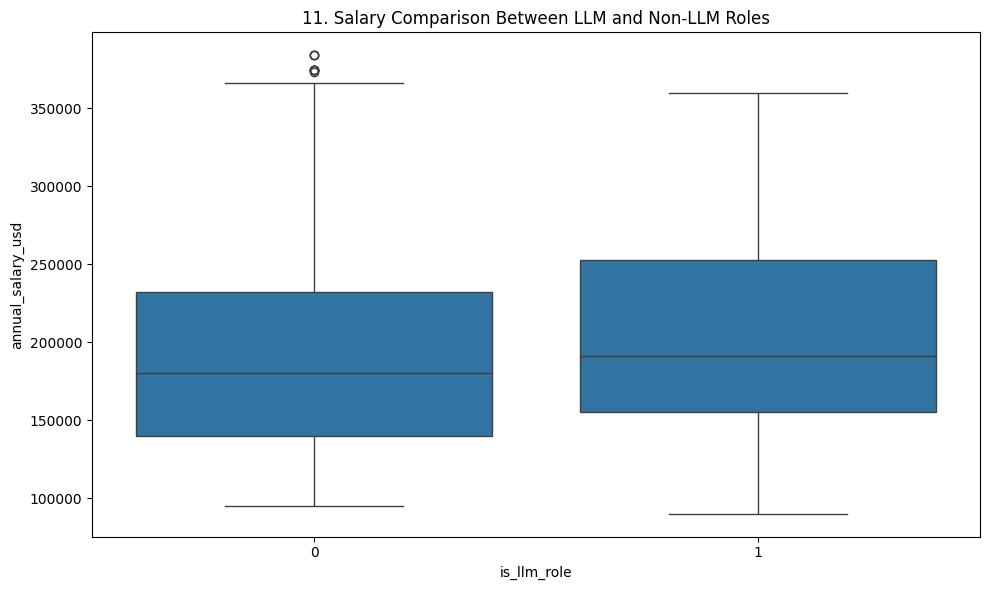

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='is_llm_role', y='annual_salary_usd')
plt.title(f'{plot_no}. Salary Comparison Between LLM and Non-LLM Roles')
show_fig()
plot_no += 1

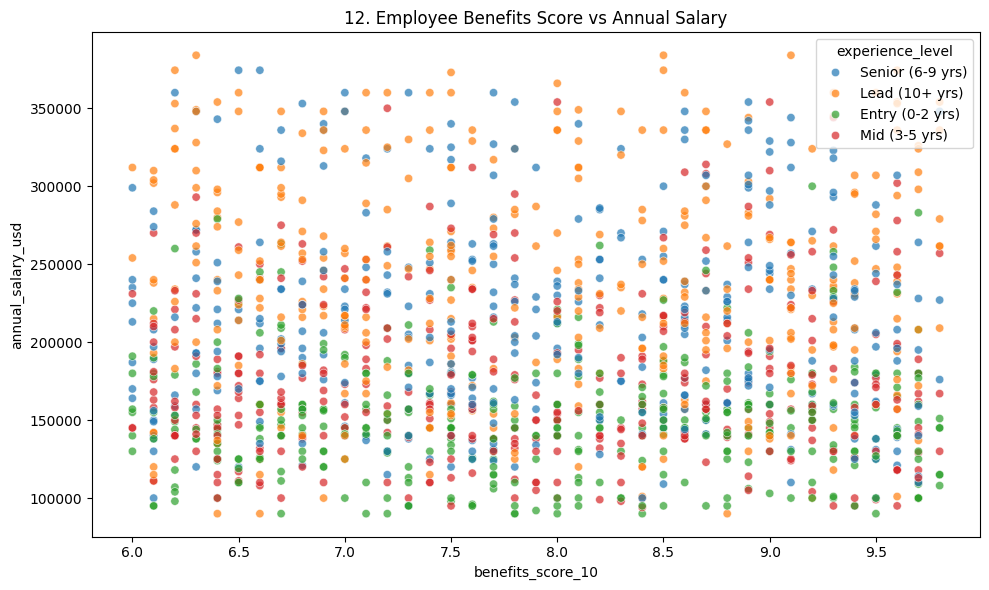

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='benefits_score_10', y='annual_salary_usd', hue='experience_level', alpha=0.7)
plt.title(f'{plot_no}. Employee Benefits Score vs Annual Salary')
show_fig()
plot_no += 1

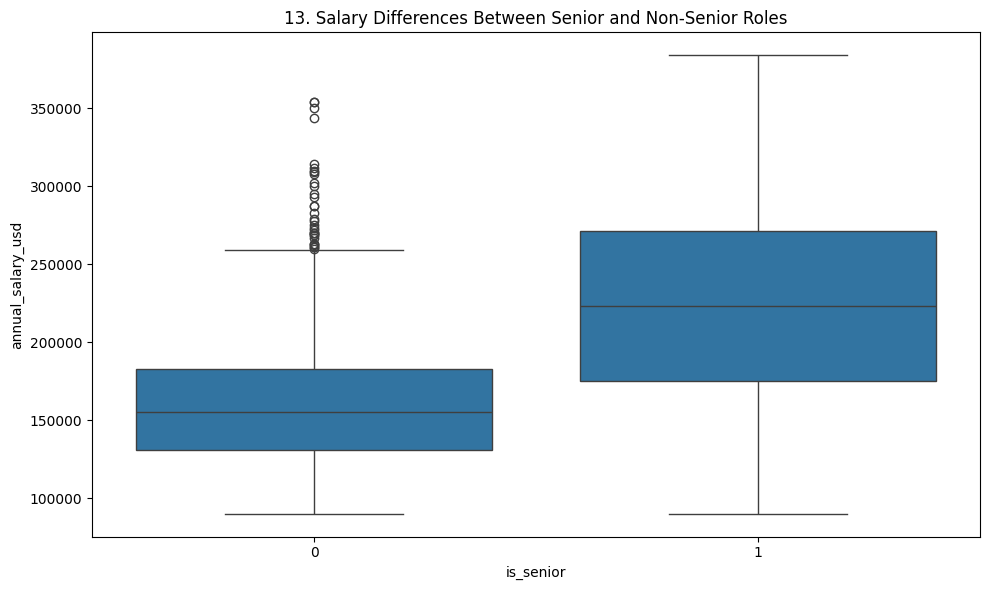

In [25]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='is_senior', y='annual_salary_usd')
plt.title(f'{plot_no}. Salary Differences Between Senior and Non-Senior Roles')
show_fig()
plot_no += 1

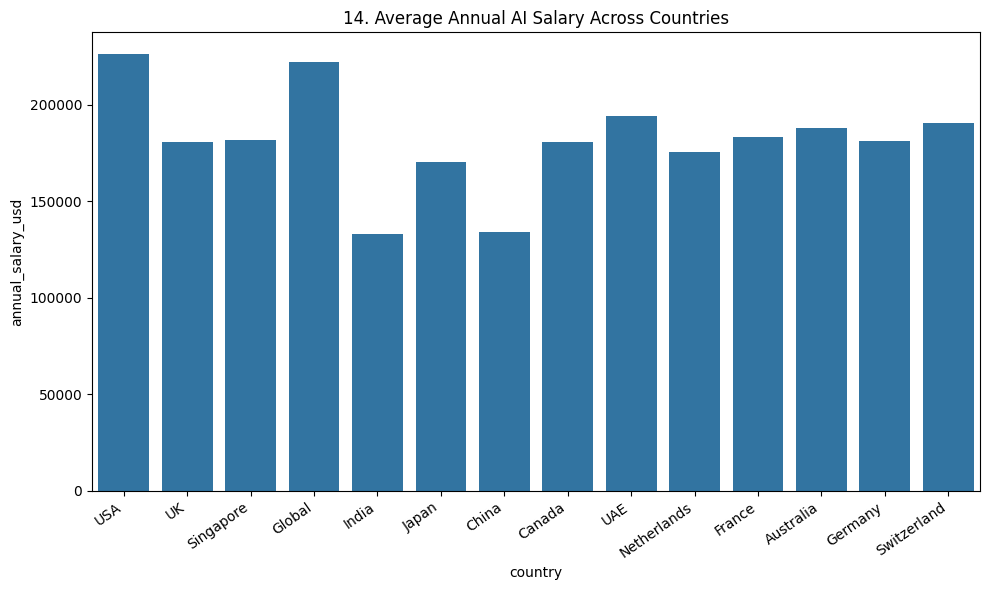

In [26]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='country', y='annual_salary_usd', errorbar=None)
plt.title(f'{plot_no}. Average Annual AI Salary Across Countries')
plt.xticks(rotation=35, ha='right')
show_fig()
plot_no += 1

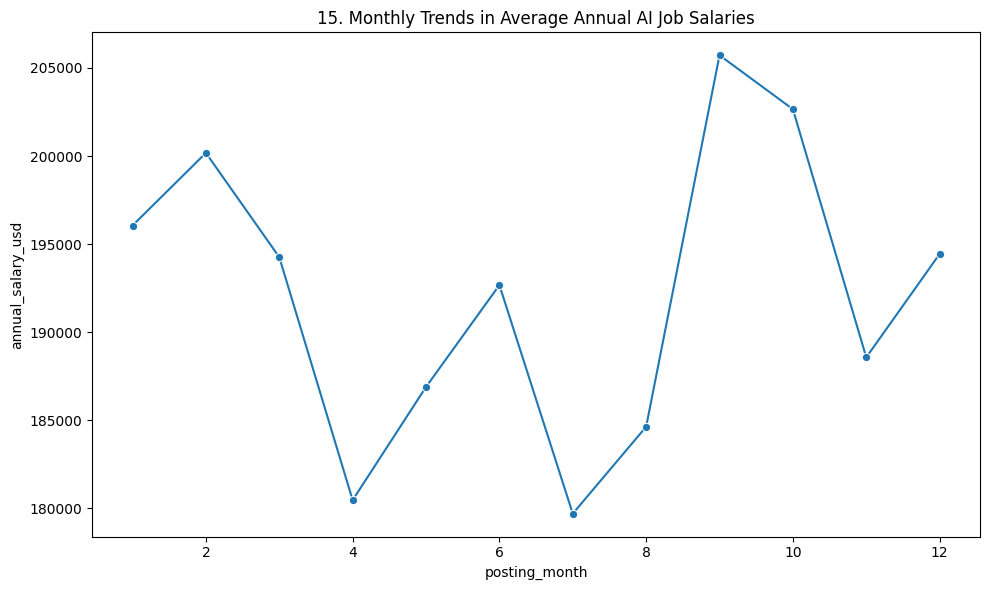

In [27]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='posting_month', y='annual_salary_usd', errorbar=None, marker='o')
plt.title(f'{plot_no}. Monthly Trends in Average Annual AI Job Salaries')
show_fig()
plot_no += 1

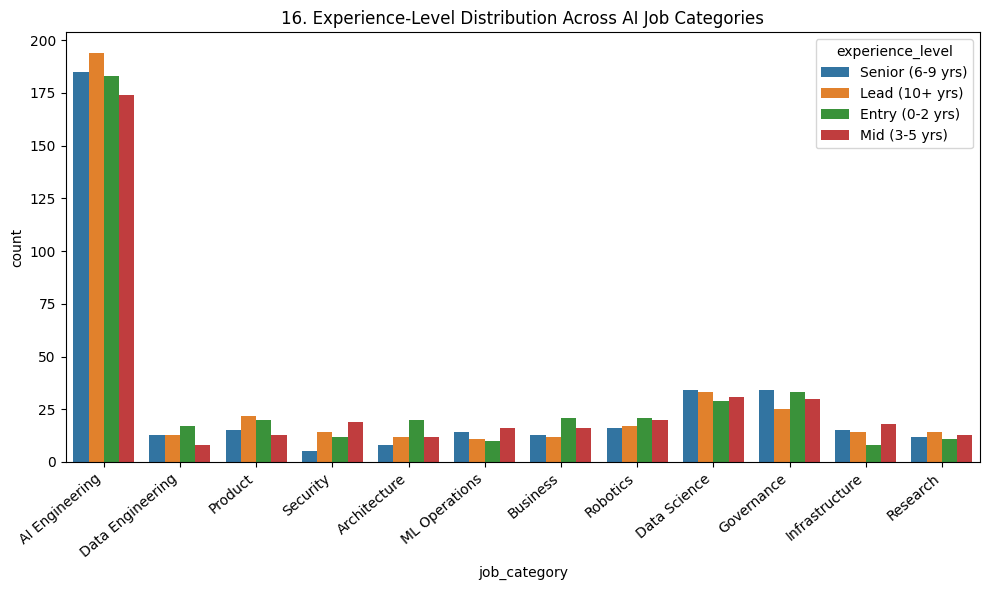

In [28]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='job_category', hue='experience_level')
plt.title(f'{plot_no}. Experience-Level Distribution Across AI Job Categories')
plt.xticks(rotation=40, ha='right')
show_fig()
plot_no += 1

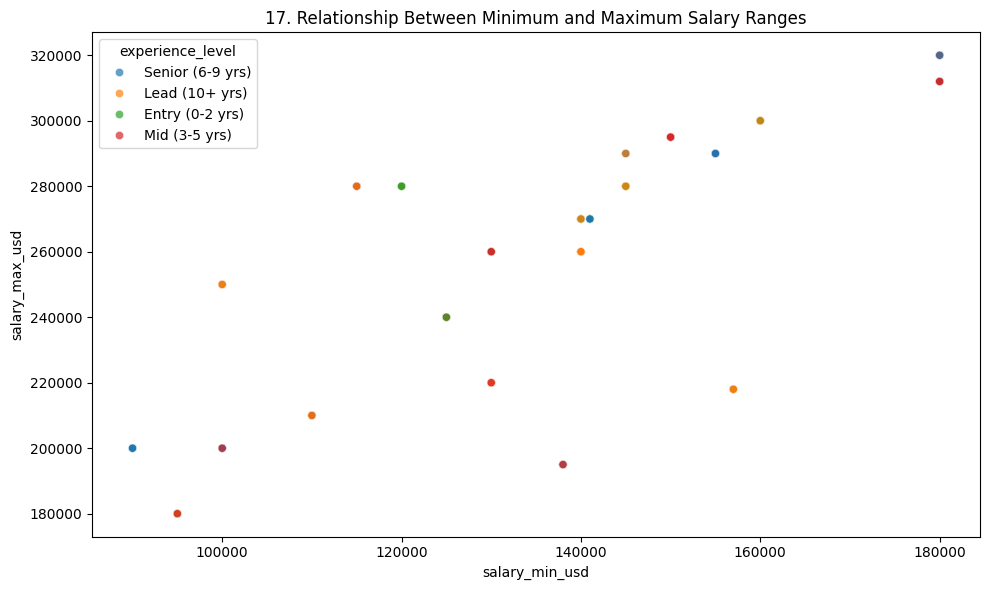

In [29]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='salary_min_usd', y='salary_max_usd', hue='experience_level', alpha=0.7)
plt.title(f'{plot_no}. Relationship Between Minimum and Maximum Salary Ranges')
show_fig()
plot_no += 1

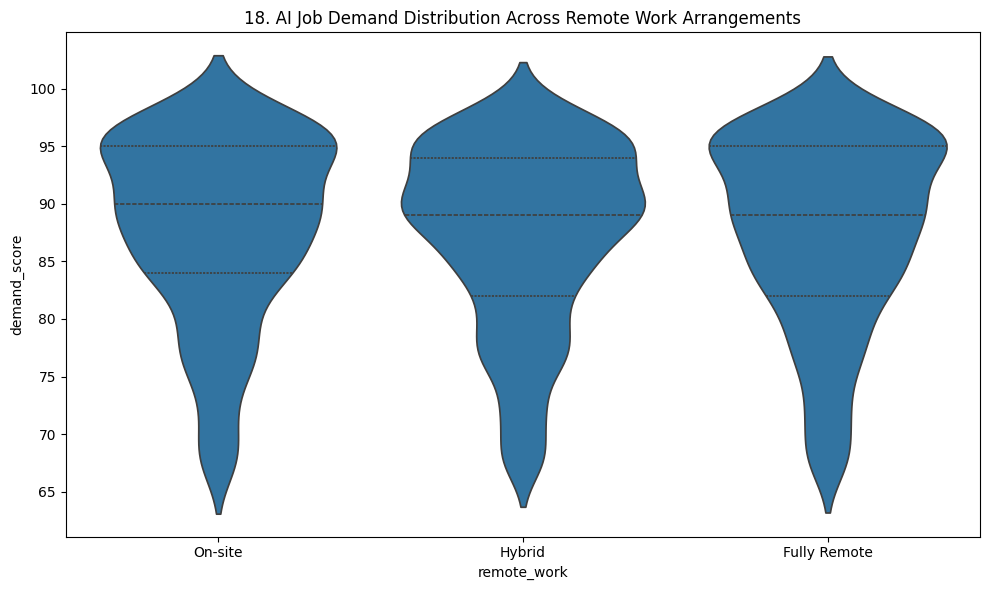

In [30]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='remote_work', y='demand_score', inner='quartile')
plt.title(f'{plot_no}. AI Job Demand Distribution Across Remote Work Arrangements')
show_fig()
plot_no += 1

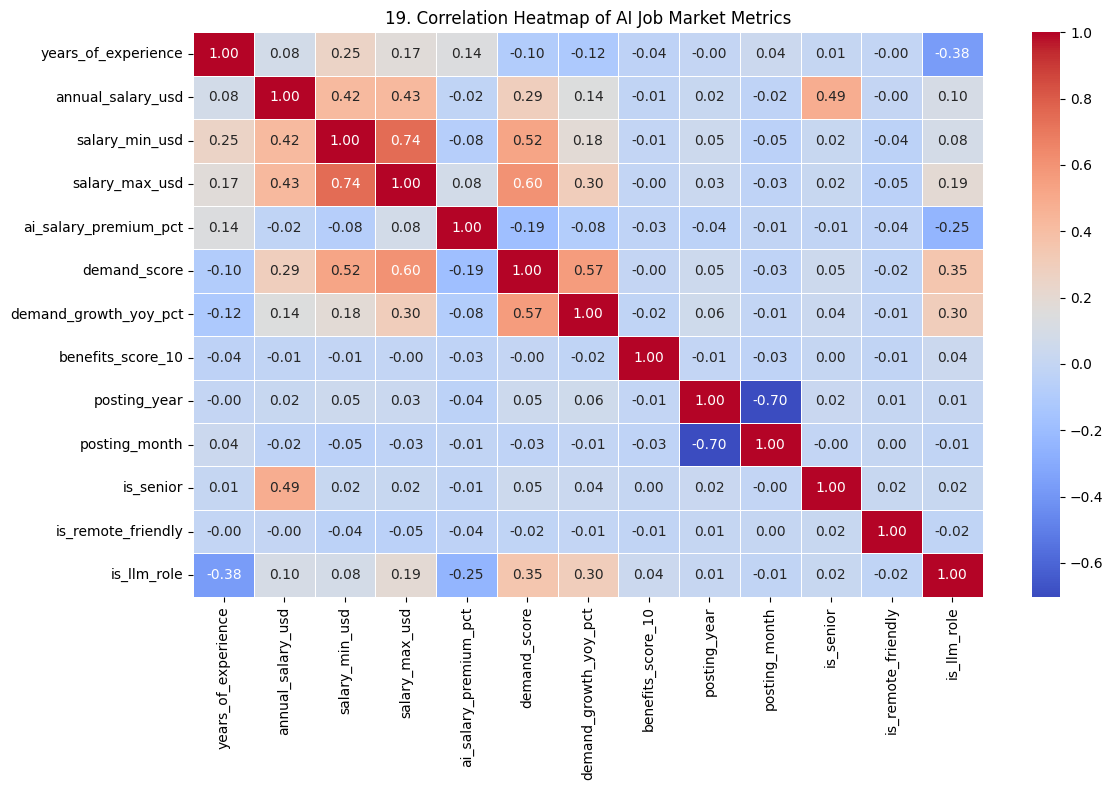

In [31]:
fig = plt.figure(figsize=(12,8))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title(f'{plot_no}. Correlation Heatmap of AI Job Market Metrics')
show_fig()
plot_no += 1

# Model Training

## Prepare data for salary prediction

In [32]:
data = df.dropna(subset=['annual_salary_usd']).copy()

X = data.drop(columns=['annual_salary_usd', 'salary_min_usd', 'salary_max_usd',
                       'salary_tier', 'job_id'])
y = data['annual_salary_usd']

## Separate numerical and categorical columns

In [33]:
num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(exclude='number').columns

## Build preprocessing pipelines

In [34]:
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

## Split data into training and testing sets

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Create and train the Extra Trees regression model

In [36]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', ExtraTreesRegressor(
        n_estimators=150,
        max_features=0.8,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Predict salaries and evaluate model performance

In [37]:
y_pred = model.predict(X_test)

print(f"R2 Accuracy Score: {r2_score(y_test, y_pred):.4f}")
print(f"R2 Score (%): {r2_score(y_test, y_pred) * 100:.2f}%")
print(f"Mean Absolute Error: ${mean_absolute_error(y_test, y_pred):,.2f}")
print(f"Root Mean Squared Error: ${mean_squared_error(y_test, y_pred) ** 0.5:,.2f}")

R2 Accuracy Score: 0.7980
R2 Score (%): 79.80%
Mean Absolute Error: $20,614.51
Root Mean Squared Error: $28,776.80


## Visualize actual vs predicted salaries

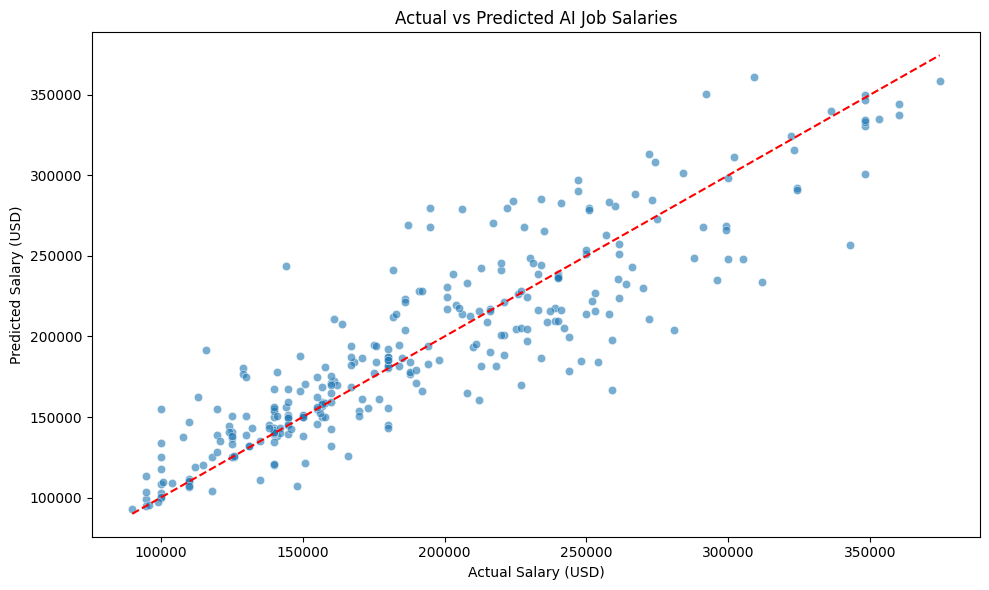

In [38]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Salary (USD)')
plt.ylabel('Predicted Salary (USD)')
plt.title('Actual vs Predicted AI Job Salaries')
show_fig()
plot_no += 1